In [ ]:
# prompt: connect to google colab

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

In [ ]:
dataset = datasets.CIFAR10(root="dataset/", transform=None, download=True)

100%|██████████| 170M/170M [00:02<00:00, 83.8MB/s]


In [ ]:
BATCH_SIZE = 512
N_CLASSES = len(dataset.classes)

EPOCHS = 100
LEARNING_RATE_CRITIC, LEARNING_RATE_GENERATOR = 0.001, 0.001

LATENT_DIMENSION = 100
FEATURES_CRITIC, FEATURES_GENERATOR = 16, 16

CRITIC_ITERATIONS = 3
LAMBDA_GP = 10

IMAGE_SIZE, IMAGE_CHANNELS = 32, 3

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
transformations = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5 for _ in range(IMAGE_CHANNELS)], [0.5 for _ in range(IMAGE_CHANNELS)]),
    ]
)

inverse_transformations = transforms.Compose(
    [
        transforms.Normalize(mean = [ 0., 0., 0. ], std = [ 1/0.229, 1/0.224, 1/0.225 ]),
        transforms.Normalize(mean = [ -0.485, -0.456, -0.406 ], std = [ 1., 1., 1. ]),
    ]
)

class CIFAR10Dataset(Dataset):
    """
    A dataset class for pedestrian detection that loads images and annotations.
    """
    def __init__(self, dataset, transforms=None):
        """
        Initializes the dataset with image paths, annotations, and optional transformations.

        Args:
            dataset (str): The dataset.
            transforms (callable, optional): A function/transform to apply to the images.
        """
        super().__init__()

        self.__dataset = dataset  # Store dataset path
        self.__transforms = transforms  # Store transformation function if provided

    def __getitem__(self, idx):
        """
        Retrieves an image and its corresponding annotations by index.

        Args:
            idx (int): Index of the image to retrieve.

        Returns:
            tuple: (image, target)
                - image (PIL Image or transformed Tensor): The image at index idx.
        """
        image = self.__dataset.data[idx]  # Get image path at index
        target = self.__dataset.targets[idx]  # Retrieve annotations

        if self.__transforms:
            image = self.__transforms(image)  # Apply transformations if available

        return image, target

    def __len__(self):
        """
        Returns the total number of images in the dataset.

        Returns:
            int: The number of images in the dataset.
        """
        return len(self.__dataset.targets)  # Return dataset size

train_dataloader = DataLoader(
                                CIFAR10Dataset(dataset=dataset, transforms=transformations),
                                batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

for real, targets in train_dataloader:
    print(real.shape, targets.shape)
    break

torch.Size([512, 3, 32, 32]) torch.Size([512])


In [ ]:
def gradient_penalty(critic, labels, real, fake, device="cpu"):
    BATCH_SIZE, C, H, W = real.shape

    alpha = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = real * alpha + fake * (1 - alpha)

    # Calculate critic scores
    mixed_scores = critic(interpolated_images, labels)

    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty

In [ ]:
class Discriminator_Task1(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator_Task1, self).__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, IMAGE_SIZE*IMAGE_SIZE)

        self.blocks = nn.Sequential(
                            nn.Conv2d(channels_img+1, features_d, kernel_size=3, stride=1, padding=1),
                            nn.LeakyReLU(0.2),
                            self._block(features_d*1, features_d*2, 3, 1, 1),
                            self._block(features_d*2, features_d*4, 3, 1, 1),
                            self._block(features_d*4, features_d*8, 3, 1, 1),
        )
        self.adv_layer = nn.Sequential(
                                        nn.Flatten(),
                                        nn.Linear(features_d*8*IMAGE_SIZE*IMAGE_SIZE, 1),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
                                nn.Conv2d(
                                                in_channels,
                                                out_channels,
                                                kernel_size,
                                                stride,
                                                padding,
                                                bias=False,
                                ),
                                nn.LeakyReLU(0.2),
        )

    def loss(self, real_scores, fake_scores):
        loss_real = torch.mean(real_scores)
        loss_fake = torch.mean(fake_scores)
        return loss_real - loss_fake

    def forward(self, x, labels):
        label_embedding = self.label_embedding(labels).view(labels.shape[0], 1, IMAGE_SIZE, IMAGE_SIZE)
        x = torch.cat((x, label_embedding), dim=1)
        x = self.blocks(x)
        x = self.adv_layer(x)
        return x

class Generator_Task1(nn.Module):
    def __init__(self, channels_noise, channels_img, features_g):
        super(Generator_Task1, self).__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, 50)

        self.blocks = nn.Sequential(
                        self._block(channels_noise+50, features_g*16, 4, 1, 0),
                        self._block(features_g*16,  features_g*8,  4, 2, 1),
                        self._block(features_g*8,   features_g*4,  4, 2, 1),
        )
        self.convtranspose2d_1 = nn.ConvTranspose2d(features_g*4, channels_img, kernel_size=4, stride=2, padding=1)
        self.tanh_1 = nn.Tanh()

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
                                nn.ConvTranspose2d(
                                                    in_channels,
                                                    out_channels,
                                                    kernel_size,
                                                    stride,
                                                    padding,
                                                    bias=False,
                                ),
                                nn.BatchNorm2d(out_channels),
                                nn.ReLU(),
        )

    def loss(self, fake_scores):
        return -torch.mean(fake_scores)

    def forward(self, x, labels):
        label_embedding = self.label_embedding(labels).unsqueeze(-1).unsqueeze(-1)
        x = torch.cat((x, label_embedding), dim=1)
        x = self.blocks(x)
        x = self.convtranspose2d_1(x)
        return self.tanh_1(x)

In [ ]:
generator_Task1 = Generator_Task1(LATENT_DIMENSION, IMAGE_CHANNELS, FEATURES_GENERATOR).to(DEVICE)
critic_Task1 = Discriminator_Task1(IMAGE_CHANNELS, FEATURES_CRITIC).to(DEVICE)

generator_path = '/content/drive/MyDrive/Colab Notebooks/data/bits/generator_task1_400.pth'
critic_path = '/content/drive/MyDrive/Colab Notebooks/data/bits/critic_task1_400.pth'
generator_Task1.load_state_dict(torch.load(generator_path, map_location=DEVICE))
critic_Task1.load_state_dict(torch.load(critic_path, map_location=DEVICE))

# initializate optimizer
optimizer_generator_Task1 = optim.Adam(generator_Task1.parameters(), lr=LEARNING_RATE_GENERATOR, betas=(0.0, 0.9))
optimizer_critic_Task1 = optim.Adam(critic_Task1.parameters(), lr=LEARNING_RATE_CRITIC, betas=(0.0, 0.9))

lr_scheduler_generator = torch.optim.lr_scheduler.StepLR(optimizer_generator_Task1, step_size=10, gamma=0.9)
lr_scheduler_critic = torch.optim.lr_scheduler.StepLR(optimizer_critic_Task1, step_size=10, gamma=0.9)

generator_Task1.train()
critic_Task1.train()

Discriminator_Task1(
  (label_embedding): Embedding(10, 1024)
  (blocks): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (adv_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=131072, out_features=1, bias=True)
  )
)

In [ ]:
for epoch in range(EPOCHS):
    bar = tqdm(
                train_dataloader,
                total=len(train_dataloader),
                desc=f"Epoch {epoch:03d}",
                unit=" batches",
    )

    for batch_idx, (real_data, target_data) in enumerate(bar, 1):
        real_data = real_data.to(DEVICE)
        target_data = target_data.to(DEVICE)
        cur_batch_size = real_data.shape[0]

        # Train Critic: max E[critic(real)] - E[critic(fake)]
        # equivalent to minimizing the negative of that
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(BATCH_SIZE, LATENT_DIMENSION, 1, 1).to(DEVICE)
            fake_data = generator_Task1(noise, target_data)

            critic_real = critic_Task1(real_data, target_data).reshape(-1)
            critic_fake = critic_Task1(fake_data, target_data).reshape(-1)
            gp = gradient_penalty(critic_Task1, target_data, real_data, fake_data, device=DEVICE)
            loss_critic = (-critic_Task1.loss(critic_real, critic_fake) + (LAMBDA_GP*gp))
            critic_Task1.zero_grad()
            loss_critic.backward(retain_graph=True)
            optimizer_critic_Task1.step()

        # Train Generator: max E[critic(gen_fake)] <-> min -E[critic(gen_fake)]
        gen_fake = critic_Task1(fake_data, target_data).reshape(-1)
        loss_gen = generator_Task1.loss(gen_fake)
        generator_Task1.zero_grad()
        loss_gen.backward()
        optimizer_generator_Task1.step()

        bar.set_postfix({
                            "D Loss" : f"{loss_critic.item():0.5f}",
                            "G Loss" : f"{loss_gen.item():0.5f}",
                            "LR G" : f"{lr_scheduler_generator.get_last_lr()[0]:0.5f}",
                            "LR D" : f"{lr_scheduler_critic.get_last_lr()[0]:0.5f}",
        })
        bar.refresh()

    lr_scheduler_generator.step()
    lr_scheduler_critic.step()

Epoch 099: 100%|██████████| 97/97 [00:23<00:00,  4.05 batches/s, D Loss=-1.48745, G Loss=144.78568, LR G=0.00039, LR D=0.00039]


In [ ]:
torch.save(generator_Task1.state_dict(), '/content/drive/MyDrive/Colab Notebooks/data/bits/generator_task1_500.pth')
torch.save(critic_Task1.state_dict(), '/content/drive/MyDrive/Colab Notebooks/data/bits/critic_task1_500.pth')

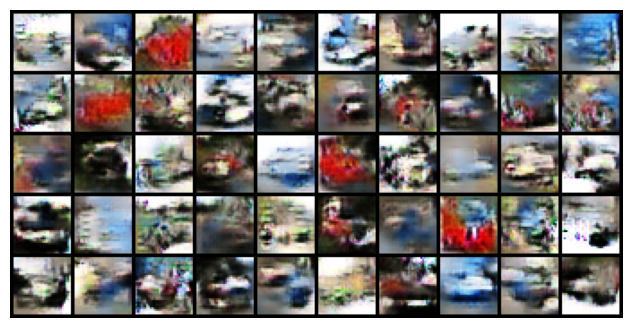

In [ ]:
# -------------------------
# Generate 10 Images for 'automobile' (class index 1)
# -------------------------
generator_Task1.eval()
num_samples = 50
auto_label = torch.full((num_samples,), 1, dtype=torch.long, device=DEVICE)  # label 1 = 'automobile'

noise = torch.randn(num_samples, LATENT_DIMENSION, 1, 1).to(DEVICE)
generator_Task1.label_embedding(auto_label).unsqueeze(-1).unsqueeze(-1).shape, noise.shape

with torch.no_grad():
    generated_imgs = generator_Task1(noise, auto_label).cpu()

# Denormalize images for display
def imshow(imgs):
    imgs = imgs * 0.5 + 0.5  # unnormalize
    grid = torchvision.utils.make_grid(imgs, nrow=10)
    npimg = grid.numpy().transpose(1, 2, 0)
    plt.figure(figsize=(8,4))
    plt.imshow(npimg)
    plt.axis("off")
    plt.show()

generated_imgs.shape

imshow(generated_imgs)

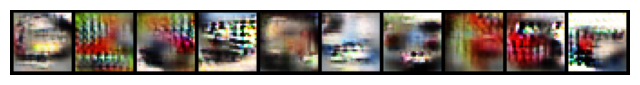

In [ ]:
# prompt: generate images from the generator for automobile

import matplotlib.pyplot as plt
# Assuming the necessary imports and model definitions are already present from the provided code.

# ... (rest of your code)

# -------------------------
# Generate 10 Images for 'automobile' (class index 1)
# -------------------------
generator_Task1.eval()
num_samples = 10  # Generate 10 images
auto_label = torch.full((num_samples,), 1, dtype=torch.long, device=DEVICE)  # label 1 = 'automobile'

noise = torch.randn(num_samples, LATENT_DIMENSION, 1, 1).to(DEVICE)

with torch.no_grad():
    generated_imgs = generator_Task1(noise, auto_label).cpu()

# Denormalize images for display
def imshow(imgs):
    imgs = imgs * 0.5 + 0.5  # unnormalize
    grid = torchvision.utils.make_grid(imgs, nrow=10)
    npimg = grid.numpy().transpose(1, 2, 0)
    plt.figure(figsize=(8, 4))
    plt.imshow(npimg)
    plt.axis("off")
    plt.show()

imshow(generated_imgs)


In [ ]:
BATCH_SIZE = 512
N_CLASSES = len(dataset.classes)

EPOCHS = 300
LEARNING_RATE_CRITIC, LEARNING_RATE_GENERATOR = 0.001, 0.001

LATENT_DIMENSION = 100
FEATURES_CRITIC, FEATURES_GENERATOR = 16, 16

CRITIC_ITERATIONS = 3

IMAGE_SIZE, IMAGE_CHANNELS = 32, 3

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

LOAD_MODEL = True
SAVE_MODEL = True

FIXED_NOISE = torch.randn(50, LATENT_DIMENSION, 1, 1).to(DEVICE)

In [ ]:
class Discriminator_Task2(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator_Task2, self).__init__()

        self.blocks = nn.Sequential(
                            nn.Conv2d(channels_img, features_d, kernel_size=3, stride=1, padding=1),
                            nn.LeakyReLU(0.2),
                            self._block(features_d*1, features_d*2, 3, 1, 1),
                            self._block(features_d*2, features_d*4, 3, 1, 1),
                            self._block(features_d*4, features_d*8, 3, 1, 1),
        )
        self.adv_layer = nn.Sequential(
                            nn.Flatten(),
                            nn.utils.spectral_norm((nn.Linear(features_d * 8 * IMAGE_SIZE * IMAGE_SIZE, 1))),
        )

        self.__initialize_weights()

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
                                nn.utils.spectral_norm(
                                    nn.Conv2d(
                                                in_channels,
                                                out_channels,
                                                kernel_size,
                                                stride,
                                                padding,
                                                bias=False,
                                )),
                                nn.LeakyReLU(0.2),
        )

    def __initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def loss(self, real_scores, fake_scores):
        loss_real = torch.mean(torch.nn.functional.relu(1. - real_scores))
        loss_fake = torch.mean(torch.nn.functional.relu(1. + fake_scores))
        return loss_real + loss_fake

    def forward(self, x):
        x = self.blocks(x)
        x = self.adv_layer(x)
        return x

class Generator_Task2(nn.Module):
    def __init__(self, channels_noise, channels_img, features_g):
        super(Generator_Task2, self).__init__()

        self.blocks = nn.Sequential(
                        self._block(channels_noise, features_g*16, 4, 1, 0),
                        self._block(features_g*16,  features_g*8,  4, 2, 1),
                        self._block(features_g*8,   features_g*4,  4, 2, 1),
        )
        self.convtranspose2d_1 = nn.ConvTranspose2d(features_g * 4, channels_img, kernel_size=4, stride=2, padding=1)
        self.tanh_1 = nn.Tanh()

        self.__initialize_weights()

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
                                nn.ConvTranspose2d(
                                                    in_channels,
                                                    out_channels,
                                                    kernel_size,
                                                    stride,
                                                    padding,
                                                    bias=False,
                                ),
                                nn.BatchNorm2d(out_channels),
                                nn.ReLU(),
        )

    def __initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def loss(self, fake_scores):
        return -torch.mean(fake_scores)

    def forward(self, x):
        x = self.blocks(x)
        x = self.convtranspose2d_1(x)
        return self.tanh_1(x)

In [ ]:
generator_Task2 = Generator_Task2(LATENT_DIMENSION, IMAGE_CHANNELS, FEATURES_GENERATOR).to(DEVICE)
critic_Task2 = Discriminator_Task2(IMAGE_CHANNELS, FEATURES_CRITIC).to(DEVICE)

if LOAD_MODEL:
    generator_path = '/content/drive/MyDrive/Colab Notebooks/data/bits/generator_task2_200.pth'
    critic_path = '/content/drive/MyDrive/Colab Notebooks/data/bits/critic_task2_200.pth'

    generator_Task2.load_state_dict(torch.load(generator_path, map_location=DEVICE))
    critic_Task2.load_state_dict(torch.load(critic_path, map_location=DEVICE))

# initializate optimizer
optimizer_generator_Task2 = optim.Adam(generator_Task2.parameters(), lr=LEARNING_RATE_GENERATOR, betas=(0.0, 0.9))
optimizer_critic_Task2 = optim.Adam(critic_Task2.parameters(), lr=LEARNING_RATE_CRITIC, betas=(0.0, 0.9))

lr_scheduler_generator = torch.optim.lr_scheduler.StepLR(optimizer_generator_Task2, step_size=20, gamma=0.9)
lr_scheduler_critic = torch.optim.lr_scheduler.StepLR(optimizer_critic_Task2, step_size=20, gamma=0.9)

generator_Task2.train()
critic_Task2.train()

Discriminator_Task2(
  (blocks): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (adv_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=131072, out_features=1, bias=True)
  )
)

In [ ]:
for epoch in range(EPOCHS):
    bar = tqdm(
                train_dataloader,
                total=len(train_dataloader),
                desc=f"Epoch {epoch:03d}",
                unit=" batches",
    )

    for batch_idx, (real_data, target_data) in enumerate(bar, 1):
        real_data = real_data.to(DEVICE)
        target_data = target_data.to(DEVICE)
        cur_batch_size = real_data.shape[0]

        # Train Critic: max E[critic(real)] - E[critic(fake)]
        # equivalent to minimizing the negative of that
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(BATCH_SIZE, LATENT_DIMENSION, 1, 1).to(DEVICE)
            fake_data = generator_Task2(noise)

            critic_real = critic_Task2(real_data).reshape(-1)
            critic_fake = critic_Task2(fake_data).reshape(-1)
            loss_critic = critic_Task2.loss(critic_real, critic_fake)
            critic_Task2.zero_grad()
            loss_critic.backward(retain_graph=True)
            optimizer_critic_Task2.step()

        # Train Generator: max E[critic(gen_fake)] <-> min -E[critic(gen_fake)]
        gen_fake = critic_Task2(fake_data).reshape(-1)
        loss_gen = generator_Task2.loss(gen_fake)
        generator_Task2.zero_grad()
        loss_gen.backward()
        optimizer_generator_Task2.step()


        bar.set_postfix({
                            "D Loss" : f"{loss_critic.item():0.5f}",
                            "G Loss" : f"{loss_gen.item():0.5f}",
                            "LR G" : f"{lr_scheduler_generator.get_last_lr()[0]:0.5f}",
                            "LR D" : f"{lr_scheduler_critic.get_last_lr()[0]:0.5f}",
        })
        bar.refresh()

    lr_scheduler_generator.step()
    lr_scheduler_critic.step()

if SAVE_MODEL:
    torch.save(generator_Task2.state_dict(), '/content/drive/MyDrive/Colab Notebooks/data/bits/generator_task2_500.pth')
    torch.save(critic_Task2.state_dict(), '/content/drive/MyDrive/Colab Notebooks/data/bits/critic_task2_500.pth')

Epoch 299: 100%|██████████| 97/97 [00:12<00:00,  7.47 batches/s, D Loss=0.38258, G Loss=1.11474, LR G=0.00023, LR D=0.00023]


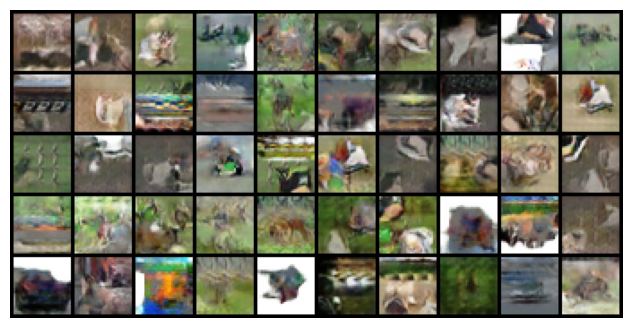

In [ ]:
generator_Task2.eval()
with torch.no_grad():
    generated_imgs = generator_Task2(FIXED_NOISE).cpu()
imshow(generated_imgs)